<a href="https://colab.research.google.com/github/mythien107/busad878/blob/main/Bullwhip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

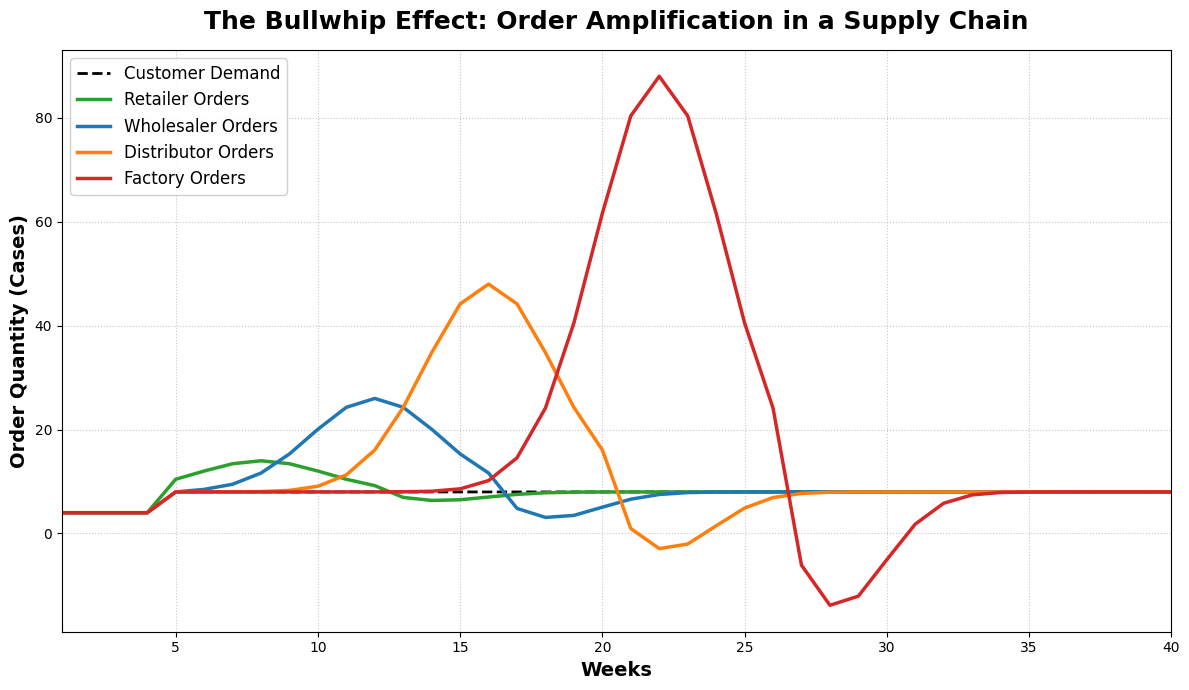

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the timeline (40 weeks)
weeks = np.arange(1, 41)

# 1. Simulate Customer Demand: 4 units until week 4, then jumps to 8
customer_demand = np.where(weeks < 5, 4, 8)

# Helper function to generate the delayed "panic" waves
def create_wave(weeks, start_week, peak_week, amplitude):
    wave = np.zeros(len(weeks))
    for i, w in enumerate(weeks):
        if w >= start_week:
            # Create a bell-like curve using an exponential function to simulate the order spike
            dist = w - peak_week
            wave[i] = amplitude * np.exp(-0.10 * (dist ** 2))

    # Add an overcorrection dip (going below the new baseline of 8) after the peak
    dip = np.zeros(len(weeks))
    for i, w in enumerate(weeks):
        if w > peak_week + 4:
            dip[i] = -(amplitude * 0.3) * np.exp(-0.15 * ((w - (peak_week + 6)) ** 2))

    # Combine the new baseline demand (8) with the panic spike and the overcorrection dip
    return np.where(weeks < 5, 4, 8 + wave + dip)

# 2. Generate the lines for each role based on typical Bullwhip amplification
# Retailer: Small panic, peaks around week 8
retailer = create_wave(weeks, start_week=5, peak_week=8, amplitude=6)

# Wholesaler: Medium panic, peaks around week 12
wholesaler = create_wave(weeks, start_week=6, peak_week=12, amplitude=18)

# Distributor: Large panic, peaks around week 16
distributor = create_wave(weeks, start_week=8, peak_week=16, amplitude=40)

# Factory: Massive panic, peaks around week 22
factory = create_wave(weeks, start_week=10, peak_week=22, amplitude=80)

# 3. Plot the data
plt.figure(figsize=(12, 7))

# Plot lines with specific, high-contrast colors
plt.plot(weeks, customer_demand, label='Customer Demand', linestyle='--', color='black', linewidth=2)
plt.plot(weeks, retailer, label='Retailer Orders', color='#2ca02c', linewidth=2.5)      # Green
plt.plot(weeks, wholesaler, label='Wholesaler Orders', color='#1f77b4', linewidth=2.5)    # Blue
plt.plot(weeks, distributor, label='Distributor Orders', color='#ff7f0e', linewidth=2.5)  # Orange
plt.plot(weeks, factory, label='Factory Orders', color='#d62728', linewidth=2.5)          # Red

# 4. Formatting the chart for a professional look
plt.title('The Bullwhip Effect: Order Amplification in a Supply Chain', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Weeks', fontsize=14, fontweight='bold')
plt.ylabel('Order Quantity (Cases)', fontsize=14, fontweight='bold')
plt.xlim(1, 40)

# Add grid lines for easier reading
plt.grid(True, linestyle=':', alpha=0.7)

# Add a legend
plt.legend(loc='upper left', fontsize=12, framealpha=0.9)

# Clean up layout and display
plt.tight_layout()
plt.show()